In [22]:
library(phyloseq)
library(NetCoMi)
library(SpiecEasi)
library(igraph)
library(dplyr)


## Import RDS file

In [23]:

## high, networks_pos is clustered only used positive correlation.
high_network <- readRDS("data/3_results/5_network_analysis/5_1_network_inference/high_network_nopos.rds")
high_network_pos <- readRDS("data/3_results/5_network_analysis/5_1_network_inference/high_network_pos.rds")
high_genus_renamed <- readRDS("data/3_results/5_network_analysis/5_1_network_inference/high_phyloseq.rds")
high_pos_genus <- high_network_pos$net_genus
high_pos_props_genus <- high_network_pos$props_genus
high_genus <- high_genus_renamed$high_genus_renamed ### phyloseq allocation by function
taxtab_high <- high_genus_renamed$taxtab_high
net_genus <- high_network$net_genus
props_genus <- high_network$props_genus

## low
low_network <- readRDS("data/3_results/5_network_analysis/5_1_network_inference/low_network_nopos.rds")
low_network_pos <- readRDS("data/3_results/5_network_analysis/5_1_network_inference/low_network_pos.rds")
low_genus_renamed <- readRDS("data/3_results/5_network_analysis/5_1_network_inference/low_phyloseq.rds")
low_pos_genus <- low_network_pos$net_genus
low_pos_props_genus <- low_network_pos$props_genus
low_genus <- low_genus_renamed$low_genus_renamed ### phyloseq allocation by function
taxtab_low <- low_genus_renamed$taxtab_low
low_net_genus <- low_network$net_genus
low_props_genus <- low_network$props_genus

## pibd
pibd_network <- readRDS("data/3_results/5_network_analysis/5_1_network_inference/pibd_network_nopos.rds")
pibd_network_pos <- readRDS("data/3_results/5_network_analysis/5_1_network_inference/pibd_network_pos.rds")
pibd_genus_renamed <- readRDS("data/3_results/5_network_analysis/5_1_network_inference/pibd_phyloseq.rds")
pibd_pos_genus <- pibd_network_pos$net_genus
pibd_pos_props_genus <- pibd_network_pos$props_genus
pibd_genus <- pibd_genus_renamed$pibd_genus_renamed ### phyloseq allocation by function
taxtab_pibd <- pibd_genus_renamed$taxtab_pibd
pibd_net_genus <- pibd_network$net_genus
pibd_props_genus <- pibd_network$props_genus


## Network summarize

## Summarize & Visualization

### MMI High

### Summarize

In [24]:
summary(high_pos_props_genus, numbNodes = 5L)


Component sizes
```````````````             
size: 97 2  1
   #:  1 1 90
______________________________
Global network properties
`````````````````````````
Largest connected component (LCC):
                                  
Relative LCC size          0.51323
Clustering coefficient     0.53895
Modularity                 0.51763
Positive edge percentage 100.00000
Edge density               0.07045
Natural connectivity       0.03393
Vertex connectivity        1.00000
Edge connectivity          1.00000
Average dissimilarity*     0.96787
Average path length**      2.38093

Whole network:
                                  
Number of components      92.00000
Clustering coefficient     0.53895
Modularity                 0.52038
Positive edge percentage 100.00000
Edge density               0.01852
Natural connectivity       0.01402
-----
*: Dissimilarity = 1 - edge weight
**: Path length = Units with average dissimilarity

______________________________
Clusters
- In the whole network
- Algo

### Visualization


Component sizes
```````````````             
size: 97 2  1
   #:  1 1 90
______________________________
Global network properties
`````````````````````````
Largest connected component (LCC):
                                  
Relative LCC size          0.51323
Clustering coefficient     0.53895
Modularity                 0.51763
Positive edge percentage 100.00000
Edge density               0.07045
Natural connectivity       0.03393
Vertex connectivity        1.00000
Edge connectivity          1.00000
Average dissimilarity*     0.96787
Average path length**      2.38093

Whole network:
                                  
Number of components      92.00000
Clustering coefficient     0.53895
Modularity                 0.52038
Positive edge percentage 100.00000
Edge density               0.01852
Natural connectivity       0.01402
-----
*: Dissimilarity = 1 - edge weight
**: Path length = Units with average dissimilarity

______________________________
Clusters
- In the whole network
- Algo


Component sizes
```````````````             
size: 97 2  1
   #:  1 1 90
______________________________
Global network properties
`````````````````````````
Largest connected component (LCC):
                                  
Relative LCC size          0.51323
Clustering coefficient     0.53895
Modularity                 0.51763
Positive edge percentage 100.00000
Edge density               0.07045
Natural connectivity       0.03393
Vertex connectivity        1.00000
Edge connectivity          1.00000
Average dissimilarity*     0.96787
Average path length**      2.38093

Whole network:
                                  
Number of components      92.00000
Clustering coefficient     0.53895
Modularity                 0.52038
Positive edge percentage 100.00000
Edge density               0.01852
Natural connectivity       0.01402
-----
*: Dissimilarity = 1 - edge weight
**: Path length = Units with average dissimilarity

______________________________
Clusters
- In the whole network
- Algo

phyla
                       __            Actinomycetota        Bacillota_A_368345 
                        1                        13                       117 
              Bacillota_C               Bacillota_I              Bacteroidota 
                        4                        22                        12 
          Cyanobacteriota Desulfobacterota_G_459543            Fusobacteriota 
                        1                         1                         1 
 Methanobacteriota_A_1229           Patescibacteria            Pseudomonadota 
                        1                         5                        10 
        Verrucomicrobiota 
                        1 

1_Bacteria(K)          Escherichia           Sutterella 
                  73                17958                   70 
    Gemmiger_A_73129 Methanobrevibacter_A Bacteroides_H_857956 
               16191                 2785                30354

pdf 
  2

pdf 
  2

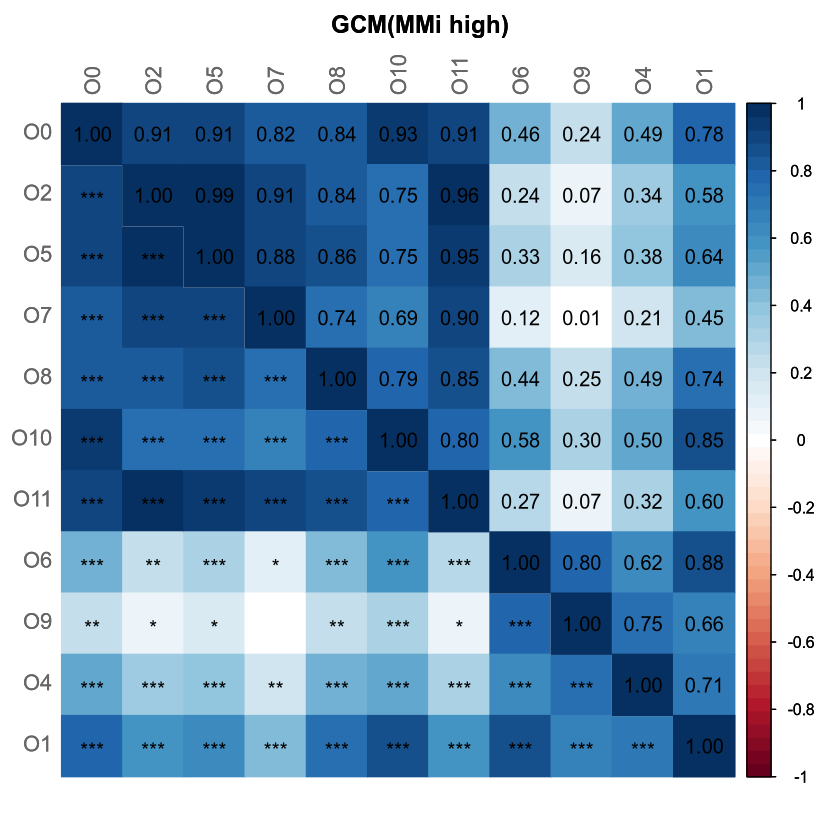

In [30]:
set.seed(123456)

summary(high_pos_props_genus)

# 3-3. Network inference & Clustering results
summary(high_pos_props_genus, numbNodes = 5L)

plotHeat(mat = high_pos_props_genus$graphletLCC$gcm1,
         pmat = high_pos_props_genus$graphletLCC$pAdjust1,
         type = "mixed",
         title = "GCM(MMi high)", 
         colorLim = c(-1, 1),
         mar = c(2, 0, 2, 0))


# 4. plot layout setting
graph3 <- igraph::graph_from_adjacency_matrix(net_genus$adjaMat1, 
                                              weighted = TRUE)
set.seed(42) # 모양 고정
ps_lay_fr <- igraph::layout_with_fr(graph3)

rownames(ps_lay_fr) <- rownames(net_genus$adjaMat1) # Row names of the layout matrix must match the node names



# 4-1. Get phyla names
taxtab <- as(tax_table(high_genus), "matrix")
phyla <- as.factor(taxtab_high[, "Phylum"])
names(phyla) <- taxa_names(high_genus)
table(phyla)

## Cluster information saving by cluster function
cluster <- high_pos_props_genus$clustering$clust1
cluster_factor <- as.factor(cluster)

total_reads <- taxa_sums(high_genus)
names(total_reads) <- taxa_names(high_genus)
head(total_reads)

positive_cluster <- high_pos_props_genus$clustering$clust1

node_names <- colnames(props_genus$input$adjaMat1)
positive_cluster <- positive_cluster[node_names]

stopifnot(
  identical(names(positive_cluster), node_names),
  !anyNA(positive_cluster)
)

# 5. network plot visualization
pdf("figure/6_network/high_filtering.pdf", width = 10, height = 8)
par(xpd=TRUE) 
## thteshold > 0.4 edge filtering Visualization
plot(
  props_genus,
  edgeInvisFilter = "threshold",
  edgeInvisPar = 0.4,
  nodeColor = "feature", # props_genus of network is positive + negative edge showed
  featVecCol = positive_cluster, # node color using positive-only clustering results.
  nodeSize = "clr",
  repulsion = 0.8,
  rmSingles = TRUE,
  labelScale = TRUE,
  cexLabels = 1.6,
  nodeSizeSpread = 3,
  cexNodes = 2,
  hubBorderCol = "black",
  posCol = "darkturquoise",
  negCol = "orange",
  title1 = paste0("Network on ASV level with SparCC correlations(MMI high)",
                  "\n(edge filter: threshold = 0.4)"),
  showTitle = TRUE,
  cexTitle = 1
)

legend(0.8, 1.1, cex = 1, title = "estimated correlation:",
       legend = c("+","-"), lty = 1, lwd = 3, col = c("darkturquoise","orange"),
       bty = "n", horiz = TRUE)
dev.off()



pdf("figure/6_network/high_non_filtering.pdf", width = 10, height = 8)
par(xpd=TRUE) 

## Edge non filtering
plot(
  props_genus,
  nodeColor = "feature", # props_genus of network is positive + negative edge showed
  featVecCol = positive_cluster, # node color using positive-only clustering results.
  nodeSize = "clr",
  repulsion = 0.8,
  rmSingles = TRUE,
  labelScale = TRUE,
  cexLabels = 1.6,
  nodeSizeSpread = 3,
  cexNodes = 2,
  hubBorderCol = "black",
  posCol = "darkturquoise",
  negCol = "orange",
  title1 = "Network on genus level with SparCC correlations (MMI-high)",
  showTitle = TRUE,
  cexTitle = 1
)
legend(0.8, 1.1, cex = 1, title = "estimated correlation:",
       legend = c("+","-"), lty = 1, lwd = 3, col = c("darkturquoise","orange"),
       bty = "n", horiz = TRUE)
dev.off()

### MMI low

### Summarize

In [26]:
summary(low_props_genus, numbNodes = 5L)


Component sizes
```````````````            
size: 108  1
   #:   1 81
______________________________
Global network properties
`````````````````````````
Largest connected component (LCC):
                                 
Relative LCC size         0.57143
Clustering coefficient    0.40865
Modularity                0.35862
Positive edge percentage 68.64407
Edge density              0.06127
Natural connectivity      0.01835
Vertex connectivity       1.00000
Edge connectivity         1.00000
Average dissimilarity*    0.97805
Average path length**     1.93357

Whole network:
                                 
Number of components     82.00000
Clustering coefficient    0.40865
Modularity                0.35862
Positive edge percentage 68.64407
Edge density              0.01993
Natural connectivity      0.00872
-----
*: Dissimilarity = 1 - edge weight
**: Path length = Units with average dissimilarity

______________________________
Clusters
- In the whole network
- Algorithm: cluster_fast_g

### Visualization

null device 
          1

phyla
                       __            Actinomycetota        Bacillota_A_368345 
                        1                        13                       117 
              Bacillota_C               Bacillota_I              Bacteroidota 
                        4                        22                        12 
          Cyanobacteriota Desulfobacterota_G_459543            Fusobacteriota 
                        1                         1                         1 
 Methanobacteriota_A_1229           Patescibacteria            Pseudomonadota 
                        1                         5                        10 
        Verrucomicrobiota 
                        1 

1_Bacteria(K)          Escherichia           Sutterella 
                  71                14377                    6 
    Gemmiger_A_73129 Methanobrevibacter_A Bacteroides_H_857956 
               10857                  796                 9672

png 
  2

png 
  2

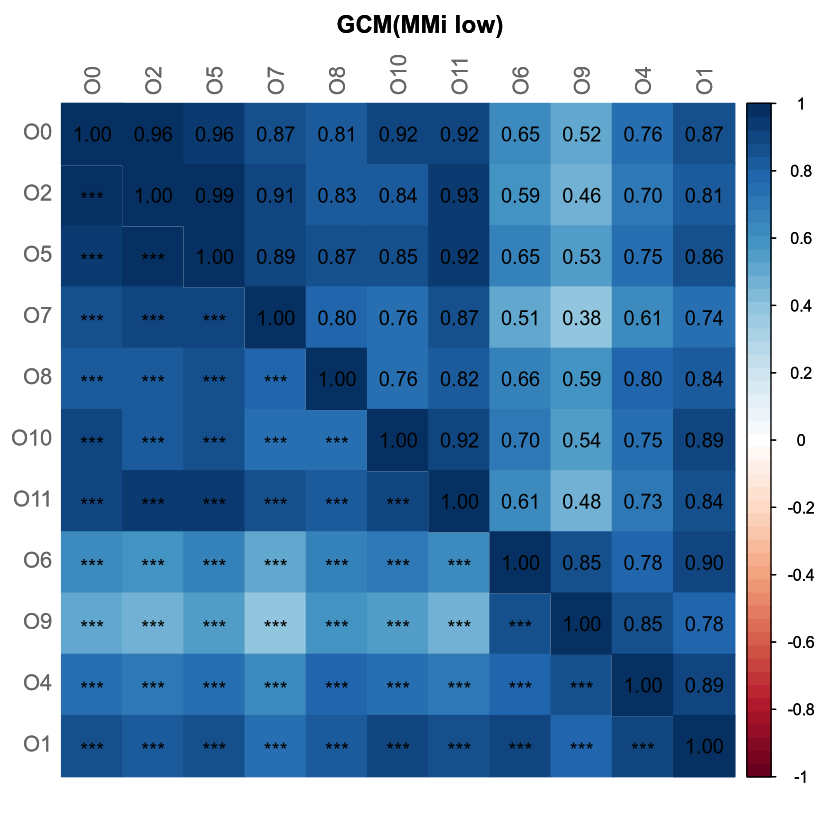

In [27]:
set.seed(123456)

plotHeat(mat = low_pos_props_genus$graphletLCC$gcm1,
         pmat = low_pos_props_genus$graphletLCC$pAdjust1,
         type = "mixed",
         title = "GCM(MMi low)", 
         colorLim = c(-1, 1),
         mar = c(2, 0, 2, 0))
dev.off()

# 4. plot layout setting
graph3 <- igraph::graph_from_adjacency_matrix(low_net_genus$adjaMat1, 
                                              weighted = TRUE)
set.seed(42) # 모양 고정
ps_lay_fr <- igraph::layout_with_fr(graph3)

rownames(ps_lay_fr) <- rownames(low_net_genus$adjaMat1) # Row names of the layout matrix must match the node names


# 4-1. Get phyla names
taxtab <- as(tax_table(low_genus), "matrix")
phyla <- as.factor(taxtab_low[, "Phylum"])
names(phyla) <- taxa_names(low_genus)
table(phyla)

## Cluster information saving by cluster function
cluster <- low_pos_props_genus$clustering$clust1
cluster_factor <- as.factor(cluster)

total_reads <- taxa_sums(low_genus)
names(total_reads) <- taxa_names(low_genus)
head(total_reads)

low_positive_cluster <- low_pos_props_genus$clustering$clust1

node_names <- colnames(low_props_genus$input$adjaMat1)
low_positive_cluster <- low_positive_cluster[node_names]

stopifnot(
  identical(names(low_positive_cluster), node_names),
  !anyNA(low_positive_cluster)
)

# 5. network plot visualization
pdf("figure/6_network/low_filtering.pdf", width = 10, height = 8)
par(xpd=TRUE) 
## thteshold > 0.4 edge filtering Visualization
plot(
  low_props_genus,
  edgeInvisFilter = "threshold",
  edgeInvisPar = 0.4,
  nodeColor = "feature", # props_genus of network is positive + negative edge showed
  featVecCol = low_positive_cluster, # node color using positive-only clustering results.
  nodeSize = "clr",
  repulsion = 0.8,
  rmSingles = TRUE,
  labelScale = TRUE,
  cexLabels = 1.6,
  nodeSizeSpread = 3,
  cexNodes = 2,
  hubBorderCol = "black",
  posCol = "darkturquoise",
  negCol = "orange",
  title1 = paste0("Network on ASV level with SparCC correlations(MMI low)",
                  "\n(edge filter: threshold = 0.4)"),
  showTitle = TRUE,
  cexTitle = 1
)
legend(0.8, 1.1, cex = 1, title = "estimated correlation:",
       legend = c("+","-"), lty = 1, lwd = 3, col = c("darkturquoise","orange"),
       bty = "n", horiz = TRUE)
dev.off()


pdf("figure/6_network/low_non_filtering.pdf", width = 10, height = 8)
## Edge non filtering
par(xpd=TRUE) 
plot(
  low_props_genus,
  nodeColor = "feature", # props_genus of network is positive + negative edge showed
  featVecCol = low_positive_cluster, # node color using positive-only clustering results.
  nodeSize = "clr",
  repulsion = 0.8,
  rmSingles = TRUE,
  labelScale = TRUE,
  cexLabels = 1.6,
  nodeSizeSpread = 3,
  cexNodes = 2,
  hubBorderCol = "black",
  posCol = "darkturquoise",
  negCol = "orange",
  title1 = paste0("Network on ASV level with SparCC correlations(MMI low)"),
  showTitle = TRUE,
  cexTitle = 1
)
legend(0.8, 1.1, cex = 1, title = "estimated correlation:",
       legend = c("+","-"), lty = 1, lwd = 3, col = c("darkturquoise","orange"),
       bty = "n", horiz = TRUE)
dev.off()


### PIBD

### Summarize

In [28]:
summary(pibd_props_genus, numbNodes = 5L)


Component sizes
```````````````               
size: 86 3 2  1
   #:  1 1 1 98
______________________________
Global network properties
`````````````````````````
Largest connected component (LCC):
                                 
Relative LCC size         0.45503
Clustering coefficient    0.27798
Modularity                0.41843
Positive edge percentage 76.10619
Edge density              0.06183
Natural connectivity      0.01886
Vertex connectivity       1.00000
Edge connectivity         1.00000
Average dissimilarity*    0.97673
Average path length**     1.97267

Whole network:
                                  
Number of components     101.00000
Clustering coefficient     0.30726
Modularity                 0.43171
Positive edge percentage  76.52174
Edge density               0.01295
Natural connectivity       0.00699
-----
*: Dissimilarity = 1 - edge weight
**: Path length = Units with average dissimilarity

______________________________
Clusters
- In the whole network
- Algorithm

### Visualization

phyla
                       __            Actinomycetota        Bacillota_A_368345 
                        1                        13                       117 
              Bacillota_C               Bacillota_I              Bacteroidota 
                        4                        22                        12 
          Cyanobacteriota Desulfobacterota_G_459543            Fusobacteriota 
                        1                         1                         1 
 Methanobacteriota_A_1229           Patescibacteria            Pseudomonadota 
                        1                         5                        10 
        Verrucomicrobiota 
                        1 

1_Bacteria(K)          Escherichia           Sutterella 
                 210                30130                  201 
    Gemmiger_A_73129 Methanobrevibacter_A Bacteroides_H_857956 
               10823                   17                27198

pdf 
  2

pdf 
  2

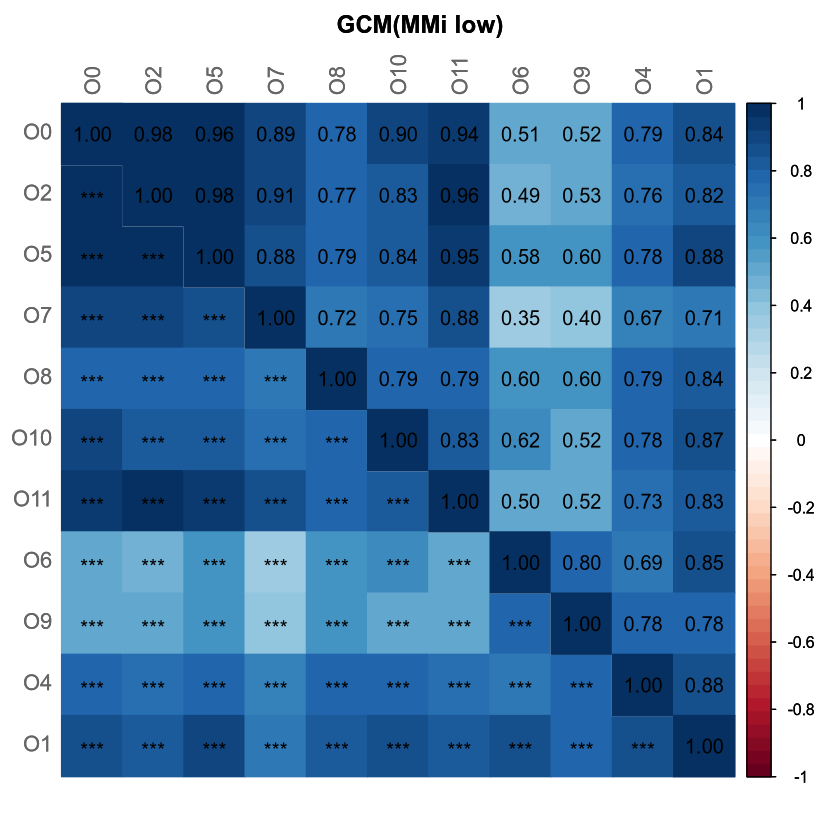

In [29]:
set.seed(123456)

plotHeat(mat = pibd_pos_props_genus$graphletLCC$gcm1,
         pmat = pibd_pos_props_genus$graphletLCC$pAdjust1,
         type = "mixed",
         title = "GCM(MMi low)", 
         colorLim = c(-1, 1),
         mar = c(2, 0, 2, 0))
#dev.off()

# 4. plot layout setting
graph3 <- igraph::graph_from_adjacency_matrix(pibd_net_genus$adjaMat1, 
                                              weighted = TRUE)
set.seed(42) # 모양 고정
ps_lay_fr <- igraph::layout_with_fr(graph3)

rownames(ps_lay_fr) <- rownames(pibd_net_genus$adjaMat1) # Row names of the layout matrix must match the node names


# 4-1. Get phyla names
taxtab <- as(tax_table(pibd_genus), "matrix")
phyla <- as.factor(taxtab_pibd[, "Phylum"])
names(phyla) <- taxa_names(pibd_genus)
table(phyla)

## Cluster information saving by cluster function
cluster <- pibd_pos_props_genus$clustering$clust1
cluster_factor <- as.factor(cluster)

total_reads <- taxa_sums(pibd_genus)
names(total_reads) <- taxa_names(pibd_genus)
head(total_reads)

positive_cluster <- pibd_pos_props_genus$clustering$clust1

node_names <- colnames(pibd_props_genus$input$adjaMat1)
positive_cluster <- positive_cluster[node_names]

stopifnot(
  identical(names(positive_cluster), node_names),
  !anyNA(positive_cluster)
)

# 5. network plot visualization
pdf("figure/6_network/pibd_filtering.pdf", width = 10, height = 8)
par(xpd=TRUE) 
## thteshold > 0.4 edge filtering Visualization
plot(
  pibd_props_genus,
  edgeInvisFilter = "threshold",
  edgeInvisPar = 0.4,
  nodeColor = "feature", # props_genus of network is positive + negative edge showed
  featVecCol = positive_cluster, # node color using positive-only clustering results.
  nodeSize = "clr",
  repulsion = 0.8,
  rmSingles = TRUE,
  labelScale = TRUE,
  cexLabels = 1.6,
  nodeSizeSpread = 3,
  cexNodes = 2,
  hubBorderCol = "black",
  posCol = "darkturquoise",
  negCol = "orange",
  title1 = paste0("Network on ASV level with SparCC correlations(PIBD)",
                  "\n(edge filter: threshold = 0.4)"),
  showTitle = TRUE,
  cexTitle = 1
)
legend(0.8, 1.1, cex = 1, title = "estimated correlation:",
       legend = c("+","-"), lty = 1, lwd = 3, col = c("darkturquoise","orange"),
       bty = "n", horiz = TRUE)
dev.off()


pdf("figure/6_network/pibd_non_filtering.pdf", width = 10, height = 8)
## Edge non filtering
par(xpd=TRUE) 
plot(
  pibd_props_genus,
  nodeColor = "feature", # props_genus of network is positive + negative edge showed
  featVecCol = positive_cluster, # node color using positive-only clustering results.
  nodeSize = "clr",
  repulsion = 0.8,
  rmSingles = TRUE,
  labelScale = TRUE,
  cexLabels = 1.6,
  nodeSizeSpread = 3,
  cexNodes = 2,
  hubBorderCol = "black",
  posCol = "darkturquoise",
  negCol = "orange",
  title1 = paste0("Network on ASV level with SparCC correlations(PIBD)"),
  showTitle = TRUE,
  cexTitle = 1
)
legend(0.8, 1.1, cex = 1, title = "estimated correlation:",
       legend = c("+","-"), lty = 1, lwd = 3, col = c("darkturquoise","orange"),
       bty = "n", horiz = TRUE)
dev.off()
